In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

Simple LR Coefficients: [1.06666667 1.00606061]
R² Score: 0.94


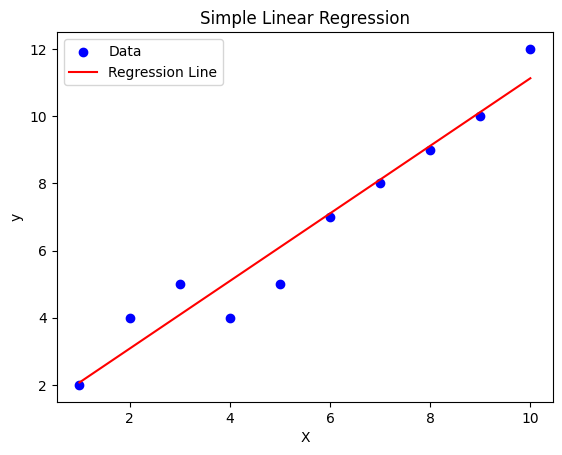

In [3]:
class SimpleLinearRegression:
    def __init__(self):
        self.coefficient_ = None
        self.intercept_ = None
        self.r2score_ = None

    def fit(self, X, y):
        n = len(X)
        X_b = np.c_[np.ones((n,1)), X]  # Add bias
        # Calculate coefficients using Normal Equation
        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.intercept_ = self.coefficients_[0]
        # Predictions
        y_pred = X_b.dot(self.coefficients_)
        # R²
        self.r2score_ = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred

    def predict(self, X):
        X_b = np.c_[np.ones((len(X),1)), X]
        return X_b.dot(self.coefficients_)
X_simple = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y_simple = np.array([2,4,5,4,5,7,8,9,10,12])
slr = SimpleLinearRegression()
slr.fit(X_simple, y_simple)
print(f"Simple LR Coefficients: {slr.coefficients_}")
print(f"R² Score: {slr.r2score_:.2f}")

plt.scatter(X_simple, y_simple, color='blue', label='Data')
plt.plot(X_simple, slr.y_pred_, color='red', label='Regression Line')
plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


Multiple LR Coefficients: [-1.45333931  2.15806389  3.32011421]
R² Score: 0.95


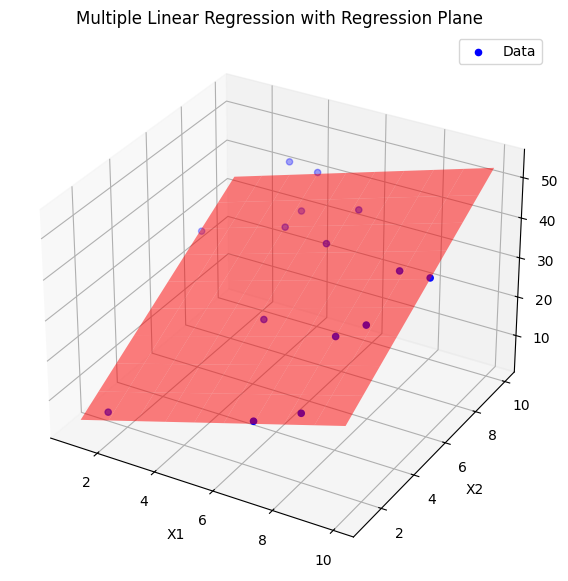

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class MultipleLinearRegression:
    def __init__(self):
        self.coefficients_ = None
        self.intercept_ = None
        self.r2score_ = None

    def fit(self, X, y):
        n = X.shape[0]
        X_b = np.c_[np.ones((n,1)), X]  # Add bias
        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.intercept_ = self.coefficients_[0]
        y_pred = X_b.dot(self.coefficients_)
        self.r2score_ = 1 - (np.sum((y - y_pred)**2)/np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred

    def predict(self, X):
        X_b = np.c_[np.ones((X.shape[0],1)), X]
        return X_b.dot(self.coefficients_)


np.random.seed(0)
X1 = np.random.randint(1, 11, 15)
X2 = np.random.randint(1, 11, 15)
X_multi = np.column_stack((X1, X2))
y_multi = 1 + 2*X1 + 3*X2 + np.random.randn(15)*2


mlr = MultipleLinearRegression()
mlr.fit(X_multi, y_multi)
print(f"Multiple LR Coefficients: {mlr.coefficients_}")
print(f"R² Score: {mlr.r2score_:.2f}")


fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_multi[:,0], X_multi[:,1], y_multi, color='blue', label='Data')

x1_surf, x2_surf = np.meshgrid(
    np.linspace(X_multi[:,0].min(), X_multi[:,0].max(), 10),
    np.linspace(X_multi[:,1].min(), X_multi[:,1].max(), 10)
)


pred_surf = mlr.predict(np.c_[x1_surf.ravel(), x2_surf.ravel()]).reshape(x1_surf.shape)


ax.plot_surface(x1_surf, x2_surf, pred_surf, color='red', alpha=0.5, rstride=1, cstride=1)

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
ax.set_title("Multiple Linear Regression with Regression Plane")
ax.legend()
plt.show()

In [8]:
class PolynomialRegression:
    def __init__(self, degree=2):
        self.degree = degree
        self.coefficients_ = None
        self.intercept_ = None
        self.r2score_ = None
        self.poly_features = None

    def fit(self, X, y):
        self.poly_features = PolynomialFeatures(degree=self.degree, include_bias=True)
        X_poly = self.poly_features.fit_transform(X)
        # Normal equation
        self.coefficients_ = np.linalg.inv(X_poly.T.dot(X_poly)).dot(X_poly.T).dot(y)
        self.intercept_ = self.coefficients_[0]
        # Predictions and R²
        y_pred = X_poly.dot(self.coefficients_)
        self.r2score_ = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred

    def predict(self, X):
        X_poly = self.poly_features.transform(X)
        return X_poly.dot(self.coefficients_)


Polynomial LR Coefficients: [2.06625067 0.91748431 0.51974149]
R² Score: 0.94


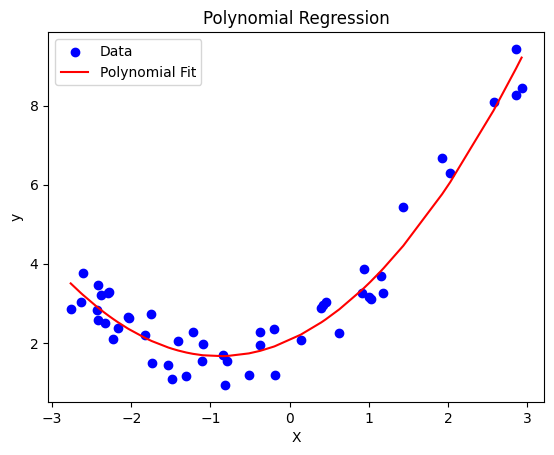

In [9]:
X_poly = np.random.rand(50,1)*6 - 3
y_poly = 0.5*X_poly**2 + X_poly + 2 + np.random.randn(50,1)*0.5
y_poly = y_poly.flatten()
pr = PolynomialRegression(degree=2)
pr.fit(X_poly, y_poly)
print(f"Polynomial LR Coefficients: {pr.coefficients_}")
print(f"R² Score: {pr.r2score_:.2f}")

# Plot
plt.scatter(X_poly, y_poly, color='blue', label='Data')
plt.plot(np.sort(X_poly, axis=0), pr.y_pred_[np.argsort(X_poly, axis=0)], color='red', label='Polynomial Fit')
plt.title("Polynomial Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()